# Variational Autoencoder — MNIST
### Practical Approach to Deep Learning — Assignment, Part 1

This notebook builds a convolutional VAE from scratch — encoder → reparameterization → decoder — trains it with the ELBO loss, and produces the three required analyses: reconstruction quality over epochs, latent interpolation between classes, and sampling from the prior.

## 1. Why a *variational* autoencoder?

A standard autoencoder learns a deterministic map $x \to z \to \hat{x}$ that minimizes reconstruction error only. Nothing forces the latent space $z$ to be *continuous* or well organized — two points close together in $z$-space can decode to completely different images, and most of the latent space decodes to garbage. That makes a plain autoencoder useless as a generative model: you can't sample a random $z$ and expect a realistic image out of it.

A VAE fixes this by treating $z$ as a random variable with a chosen prior $p(z) = \mathcal{N}(0, I)$, and training the encoder to output a *distribution* $q_\phi(z|x) = \mathcal{N}(\mu, \mathrm{diag}(\sigma^2))$ rather than a single point. Regularizing $q_\phi(z|x)$ toward that prior during training is exactly what makes the latent space continuous and sampleable — which is the whole point of the KL term below.

## 2. Deriving the ELBO

We want to maximize the log-likelihood of the data, $\log p_\theta(x) = \log \int p_\theta(x, z)\, dz$. That integral is intractable — it means integrating over every possible $z$ — so we introduce the encoder $q_\phi(z|x)$ as an approximate posterior and rewrite it as an expectation:

$$
\log p_\theta(x) = \log \int q_\phi(z|x) \, \frac{p_\theta(x,z)}{q_\phi(z|x)} \, dz = \log \, \mathbb{E}_{q_\phi(z|x)}\!\left[\frac{p_\theta(x,z)}{q_\phi(z|x)}\right]
$$

Since $\log$ is concave, Jensen's inequality gives $\log \mathbb{E}[Y] \ge \mathbb{E}[\log Y]$, so:

$$
\log p_\theta(x) \;\ge\; \mathbb{E}_{q_\phi(z|x)}\Big[\log p_\theta(x|z) + \log p(z) - \log q_\phi(z|x)\Big] = \underbrace{\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)] - D_{KL}\big(q_\phi(z|x) \,\|\, p(z)\big)}_{\text{ELBO}}
$$

That right-hand side is the **Evidence Lower BOund**. Equivalently, $\log p_\theta(x) = \text{ELBO} + D_{KL}(q_\phi(z|x)\,\|\,p_\theta(z|x))$ — the gap between the true log-likelihood and the ELBO is exactly the KL divergence between our approximate posterior and the true (intractable) posterior. Because KL is always $\ge 0$, the ELBO really is a lower bound, and maximizing it does two things at once: it pulls $q_\phi(z|x)$ toward the true posterior, and it pushes up the log-likelihood of the data.

Flip the sign to get something to *minimize*:

$$
\mathcal{L}_{\text{VAE}} = -\text{ELBO} = \underbrace{-\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]}_{\text{reconstruction term}} + \underbrace{D_{KL}\big(q_\phi(z|x)\,\|\,\mathcal{N}(0,I)\big)}_{\text{KL term}}
$$

The reconstruction term becomes **binary cross-entropy** if each output pixel is modelled as Bernoulli, or **MSE** (up to a constant) if it's modelled as Gaussian with fixed variance — that's why the brief allows either.

## 3. The reparameterization trick

We need to backpropagate through a *sampling* step, $z \sim q_\phi(z|x)$ — and you can't take a gradient through a random sampling operation directly, there's no $\partial z / \partial \phi$ when $z$ is drawn stochastically from a distribution whose parameters depend on $\phi$.

The fix: instead of sampling $z$ directly, sample noise from a fixed, parameter-free distribution and pass it through a deterministic function of $\mu_\phi(x)$ and $\sigma_\phi(x)$:

$$
\varepsilon \sim \mathcal{N}(0, I), \qquad z = \mu_\phi(x) + \sigma_\phi(x) \odot \varepsilon
$$

The randomness is now isolated in $\varepsilon$, which does not depend on $\phi$, so gradients flow cleanly through $\mu$ and $\sigma$ via ordinary backprop. That's the entire trick — it's a change of variables, not an approximation.

## 4. Closed-form KL divergence (Gaussian vs. standard normal)

Because $q_\phi(z|x)$ and the prior are both Gaussian, and we assume a diagonal covariance (independent latent dimensions), the KL divergence has a closed form — no Monte-Carlo estimate needed. For a single dimension, $q = \mathcal{N}(\mu, \sigma^2)$ against $p = \mathcal{N}(0,1)$:

$$
D_{KL}(q\|p) = \mathbb{E}_q\big[\log q(z) - \log p(z)\big]
$$

Substituting the Gaussian log-densities and using $\mathbb{E}_q[(z-\mu)^2] = \sigma^2$ and $\mathbb{E}_q[z^2] = \sigma^2 + \mu^2$:

$$
D_{KL}(q\|p) = -\log\sigma - \tfrac{1}{2} + \tfrac{1}{2}(\sigma^2+\mu^2) = \tfrac{1}{2}\big(\sigma^2 + \mu^2 - 1 - \log\sigma^2\big)
$$

Summing over the $D$ independent latent dimensions — this is exactly why the diagonal-covariance assumption matters, it's what lets the multivariate KL collapse into a sum of 1-D terms:

$$
D_{KL} = -\frac{1}{2}\sum_{j=1}^{D}\Big(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\Big)
$$

which is exactly the formula in the brief. In code the encoder predicts $\log \sigma^2$ rather than $\sigma$ or $\sigma^2$ directly, because $\sigma^2$ must stay positive but its log is numerically unconstrained — the network can output any real number and it still exponentiates to something valid.

The cell below imports necessary Python libraries for building and training the Variational Autoencoder (VAE):

*   `torch`: The main PyTorch library for neural networks.
*   `torch.nn`: Contains modules for building neural network layers (e.g., `Conv2d`, `Linear`).
*   `torch.nn.functional`: Provides functional interfaces for common neural network operations (e.g., activation functions, loss functions).
*   `torch.utils.data.DataLoader`: Utility for batching and shuffling datasets.
*   `torchvision.datasets`: Provides standard datasets like MNIST.
*   `torchvision.transforms`: Offers common image transformations.
*   `matplotlib.pyplot`: Used for plotting and visualizing data.

It then sets a random seed for reproducibility (`torch.manual_seed(42)`) and determines if a GPU (CUDA) is available for training, falling back to CPU if not. This ensures the model runs efficiently on the available hardware.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


The cell below defines hyperparameters for the VAE model and training process:

*   `LATENT_DIM`: The dimensionality of the latent space (16 in this case). This determines the size of the compressed representation of the input.
*   `BATCH_SIZE`: The number of samples processed in each training iteration (128).
*   `LR`: The learning rate for the AdamW optimizer (1e-3, or 0.001).
*   `EPOCHS`: The total number of times the training dataset will be passed through the model (15).
*   `BETA`: The weight applied to the KL divergence term in the VAE loss function (1.0). This controls the balance between reconstruction accuracy and latent space regularization.

In [ ]:
LATENT_DIM = 16   # latent dimension is set to 16
BATCH_SIZE = 128
LR = 1e-3
EPOCHS = 15
BETA = 1.0

The cell below prepares the MNIST dataset for training and testing:

*   `transforms.ToTensor()`: Converts images to PyTorch tensors and scales pixel values from `[0, 255]` to `[0, 1]`. This is crucial because the Binary Cross-Entropy (BCE) loss function typically expects target values in this range.
*   `datasets.MNIST(...)`: Downloads and loads the MNIST dataset. It's split into `train_set` (60,000 images) and `test_set` (10,000 images).
*   `DataLoader(...)`: Creates data loaders for both training and testing. These loaders handle batching, shuffling (for the training set), and iterating through the dataset efficiently.

In [ ]:
transform = transforms.ToTensor()  # scales pixels to [0, 1] — required, since BCE below expects targets in that range

# Using MNIST dataset
train_set = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_set  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_set)} | Test: {len(test_set)}")

Train: 60000 | Test: 10000


The cell below defines the `Encoder` class, which is a key component of the VAE. Its purpose is to map an input image to the parameters (mean `mu` and logarithm of variance `logvar`) of the latent distribution $q_\phi(z|x)$.

*   `__init__`: Initializes the convolutional layers (`conv1`, `conv2`) to reduce the spatial dimensions of the image and increase feature channels. `fc_mu` and `fc_logvar` are fully connected layers that output the `mu` (mean) and `logvar` (log-variance) of the latent space, respectively.
*   `forward`: Defines the forward pass. It applies convolutional layers with ReLU activations, flattens the output, and then passes it through the fully connected layers to produce `mu` and `logvar`.

In [ ]:
class Encoder(nn.Module):
    '''Maps an image to the parameters (mu, logvar) of q_phi(z|x).'''
    def __init__(self, latent_dim=LATENT_DIM, in_channels=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=4, stride=2, padding=1)  # 28x28 -> 14x14
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)           # 14x14 -> 7x7
        self.flatten_dim = 64 * 7 * 7
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)
    def forward(self, x):
        h = F.relu(self.conv1(x))
        h = F.relu(self.conv2(h))
        h = h.view(h.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

The cell below defines the `Decoder` class, which takes a latent vector `z` and reconstructs an image from it.

*   `__init__`: Initializes a fully connected layer (`fc`) to expand the latent vector back to a higher-dimensional representation, followed by transposed convolutional layers (`deconv1`, `deconv2`). Transposed convolutions are used to upsample the feature maps.
*   `forward`: Defines the forward pass. It takes the latent vector `z`, passes it through the fully connected layer and ReLU activation, reshapes it, then applies transposed convolutions with ReLU activations. Finally, a `sigmoid` activation is applied to the last layer to ensure the output pixel values are in the `[0, 1]` range, matching the expected input for BCE loss.

In [ ]:
class Decoder(nn.Module):
    '''Maps a latent vector z back to image space.'''
    def __init__(self, latent_dim=LATENT_DIM, out_channels=1):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 64 * 7 * 7)
        self.deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)           # 7x7 -> 14x14
        self.deconv2 = nn.ConvTranspose2d(32, out_channels, kernel_size=4, stride=2, padding=1) # 14x14 -> 28x28

    def forward(self, z):
        h = F.relu(self.fc(z))
        h = h.view(h.size(0), 64, 7, 7)
        h = F.relu(self.deconv1(h))
        x_recon = torch.sigmoid(self.deconv2(h))  # pixels in [0,1], matching BCE's expected input range
        return x_recon

The cell below defines the `VAE` class, which combines the `Encoder` and `Decoder` into a complete Variational Autoencoder model.

*   `__init__`: Initializes instances of the `Encoder` and `Decoder`.
*   `reparameterize`: Implements the reparameterization trick. Instead of directly sampling `z` from $N(\mu, \sigma^2)$, it samples `eps` (noise) from a standard normal distribution $N(0, I)$ and calculates $z = \mu + \text{std} \odot \text{eps}$, where $\text{std} = \exp(0.5 \times \text{logvar})$. This allows gradients to flow through `mu` and `logvar` during backpropagation.
*   `forward`: Defines the forward pass of the VAE. It takes an input image `x`, encodes it to `mu` and `logvar`, reparameterizes to get `z`, and then decodes `z` to reconstruct the image `x_recon`.

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, in_channels=1):
        super().__init__()
        self.encoder = Encoder(latent_dim, in_channels)
        self.decoder = Decoder(latent_dim, in_channels)

    def reparameterize(self, mu, logvar):
        # z = mu + sigma * eps, eps ~ N(0,I) — reparameterization-trick
        std = torch.exp(0.5 * logvar)      # sigma = sqrt(exp(logvar))
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

The cell below defines the `vae_loss` function, which calculates the Negative Evidence Lower Bound (ELBO) as the training objective.

*   `recon`: This is the reconstruction loss, calculated using `F.binary_cross_entropy` between the original image `x` and its reconstruction `x_recon`. `reduction="sum"` sums the loss over all pixels in a batch, and then it's averaged `per image` by dividing by `x.size(0)` (batch size).
*   `kl`: This is the KL divergence loss, which measures how much the learned latent distribution $q_\phi(z|x)$ deviates from the standard normal prior $p(z) = N(0, I)$. The closed-form expression for KL divergence between two normal distributions is used here. It's also summed over the batch and then averaged per image.
*   The function returns the total VAE loss (`recon + beta * kl`), as well as the individual `recon` and `kl` terms for monitoring.

In [ ]:
def vae_loss(x_recon, x, mu, logvar, beta=1.0):
    '''Negative ELBO = reconstruction term + beta * KL term (summed over the batch, then averaged per image).'''
    recon = F.binary_cross_entropy(x_recon, x, reduction="sum") / x.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon + beta * kl, recon, kl

The cell below defines the `train_vae` function, which orchestrates the entire training process.

*   It initializes a `VAE` model and an `AdamW` optimizer.
*   It fixes a small batch of test images (`fixed_x`) to visualize reconstruction quality over epochs.
*   It iterates through the specified number of `epochs`:
    *   **Training Loop**: For each batch in `train_loader`, it performs a forward pass, calculates the VAE loss, performs backpropagation (`loss.backward()`), and updates model weights (`optimizer.step()`). It also tracks running losses.
    *   **Evaluation (Snapshot)**: After each epoch, it sets the model to evaluation mode (`model.eval()`) and reconstructs the `fixed_x` images without calculating gradients. These reconstructions are saved as `snapshots`.
    *   It prints the epoch, total loss, reconstruction loss, and KL loss.
*   Finally, it returns the trained `model`, `history` of losses, `snapshots`, and the `fixed_x` originals.

In [ ]:
def train_vae(beta=BETA, epochs=EPOCHS, latent_dim=LATENT_DIM):
    model = VAE(latent_dim=latent_dim).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

    # fix one batch from the test set so "reconstruction over epochs" compares the SAME images every time
    fixed_x, _ = next(iter(test_loader))
    fixed_x = fixed_x[:8].to(device)

    history = {"loss": [], "recon": [], "kl": []}
    snapshots = []  # (epoch, reconstructed fixed_x) — used for the report figure

    for epoch in range(1, epochs + 1):
        model.train()
        running = {"loss": 0.0, "recon": 0.0, "kl": 0.0}
        for x, _ in train_loader:
            x = x.to(device)
            x_recon, mu, logvar = model(x)
            loss, recon, kl = vae_loss(x_recon, x, mu, logvar, beta=beta)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running["loss"] += loss.item() * x.size(0)
            running["recon"] += recon.item() * x.size(0)
            running["kl"] += kl.item() * x.size(0)

        n = len(train_set)
        for k in history:
            history[k].append(running[k] / n)

        model.eval()
        with torch.no_grad():
            recon_fixed, _, _ = model(fixed_x)
        snapshots.append((epoch, recon_fixed.cpu()))

        print(f"epoch {epoch:2d} | loss {history['loss'][-1]:.2f} | recon {history['recon'][-1]:.2f} | kl {history['kl'][-1]:.2f}")

    return model, history, snapshots, fixed_x.cpu()

model, history, snapshots, fixed_x = train_vae()

epoch  1 | loss 178.08 | recon 162.25 | kl 15.83
epoch  2 | loss 115.88 | recon 92.86 | kl 23.02
epoch  3 | loss 109.93 | recon 86.40 | kl 23.53
epoch  4 | loss 107.27 | recon 83.48 | kl 23.79
epoch  5 | loss 105.59 | recon 81.69 | kl 23.91
epoch  6 | loss 104.56 | recon 80.51 | kl 24.05
epoch  7 | loss 103.71 | recon 79.57 | kl 24.15
epoch  8 | loss 102.98 | recon 78.82 | kl 24.16
epoch  9 | loss 102.41 | recon 78.22 | kl 24.19
epoch 10 | loss 101.96 | recon 77.75 | kl 24.20
epoch 11 | loss 101.54 | recon 77.32 | kl 24.23
epoch 12 | loss 101.20 | recon 76.95 | kl 24.25
epoch 13 | loss 100.88 | recon 76.63 | kl 24.25
epoch 14 | loss 100.59 | recon 76.37 | kl 24.22
epoch 15 | loss 100.35 | recon 76.14 | kl 24.20


The cell below visualizes the training loss curves.

*   It plots the total VAE loss, reconstruction loss, and KL divergence loss over the training epochs.
*   This plot helps monitor the training progress and diagnose potential issues like posterior collapse (where the KL term drops to zero early), which is mentioned in the comments.

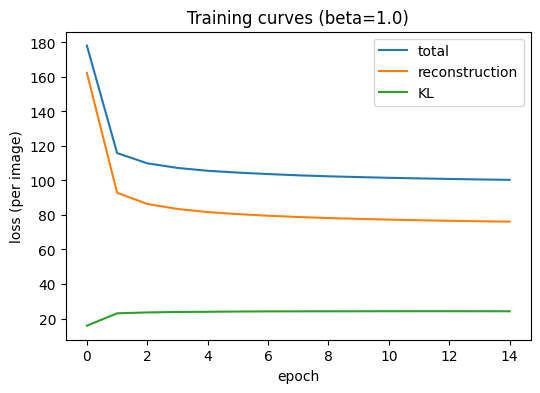

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history["loss"], label="total")
plt.plot(history["recon"], label="reconstruction")
plt.plot(history["kl"], label="KL")
plt.xlabel("epoch"); plt.ylabel("loss (per image)"); plt.legend()
plt.title(f"Training curves (beta={BETA})")
plt.show()

# KL curve: if it collapses toward 0 early, that's "posterior collapse" — the encoder stops encoding useful information and the decoder falls back
# on modelling p(x) unconditionally.

The cell below visualizes the reconstruction quality of the VAE over several epochs.

*   It selects specific epochs (start, middle, end of training) to show a progression.
*   It displays the original `fixed_x` images in the top row.
*   In subsequent rows, it shows the reconstructed versions of these same `fixed_x` images from the selected epochs. This allows for a visual assessment of how the model's ability to reconstruct images improves during training.

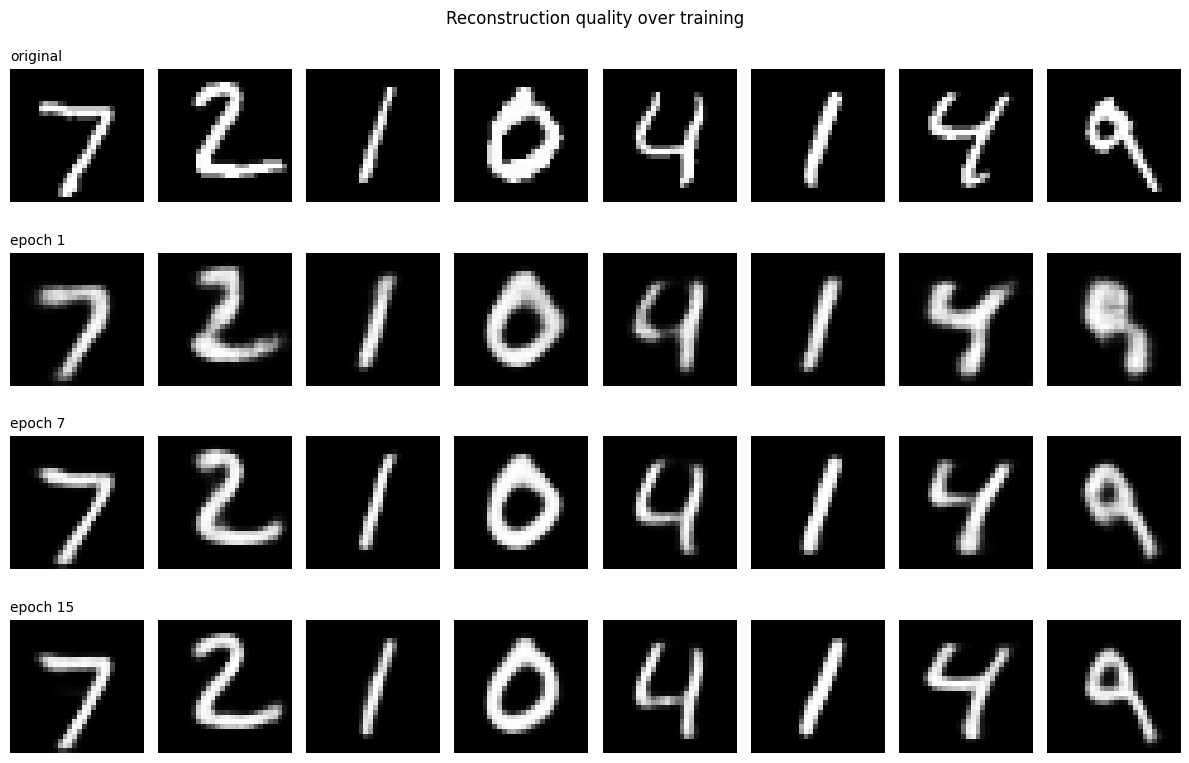

In [ ]:
show_epochs = sorted(set([1, EPOCHS // 2, EPOCHS]))
snap = dict(snapshots)

fig, axes = plt.subplots(len(show_epochs) + 1, 8, figsize=(12, 2 * (len(show_epochs) + 1)))

for col in range(8):
    axes[0, col].imshow(fixed_x[col, 0].numpy(), cmap="gray")
    axes[0, col].axis("off")
axes[0, 0].set_title("original", loc="left", fontsize=10)

for row, ep in enumerate(show_epochs, start=1):
    recon = snap[ep]
    for col in range(8):
        axes[row, col].imshow(recon[col, 0].numpy(), cmap="gray")
        axes[row, col].axis("off")
    axes[row, 0].set_title(f"epoch {ep}", loc="left", fontsize=10)

plt.suptitle("Reconstruction quality over training")
plt.tight_layout()
plt.show()

The cell below demonstrates latent space interpolation, showing how the VAE transitions smoothly between two different digits in the latent space.

*   It retrieves two specific digits (e.g., '0' and '9') from the test set.
*   It encodes these images to get their latent means (`mu_a` and `mu_b`).
*   It creates a series of interpolated latent vectors (`z_interp`) by linearly interpolating between `mu_a` and `mu_b` using `alphas` (values from 0 to 1).
*   Each interpolated `z` is then passed through the `decoder` to generate an image.
*   The resulting interpolated images are displayed, illustrating the continuous nature of the learned latent space.

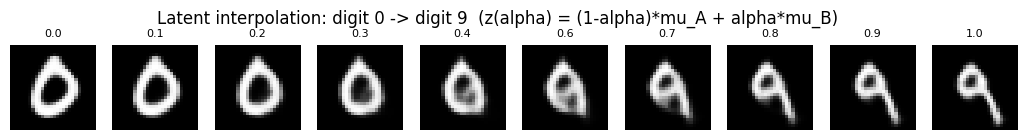

In [ ]:
def get_one_example(dataset, label):
    for x, y in dataset:
        if y == label:
            return x
    raise ValueError(f"label {label} not found")

img_a = get_one_example(test_set, 0).unsqueeze(0).to(device)   # digit '0'
img_b = get_one_example(test_set, 9).unsqueeze(0).to(device)   # digit '9'

model.eval()
with torch.no_grad():
    mu_a, _ = model.encoder(img_a)
    mu_b, _ = model.encoder(img_b)

    steps = 10
    alphas = torch.linspace(0, 1, steps).to(device)
    # interpolate the MEANS, not a freshly sampled z — that keeps the path deterministic instead of jittering around from the eps noise at each step
    z_interp = torch.stack([(1 - a) * mu_a.squeeze(0) + a * mu_b.squeeze(0) for a in alphas])
    imgs_interp = model.decoder(z_interp).cpu()

fig, axes = plt.subplots(1, steps, figsize=(steps * 1.3, 1.6))
for i in range(steps):
    axes[i].imshow(imgs_interp[i, 0].numpy(), cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"{alphas[i]:.1f}", fontsize=8)
plt.suptitle("Latent interpolation: digit 0 -> digit 9  (z(alpha) = (1-alpha)*mu_A + alpha*mu_B)")
plt.show()

The cell below demonstrates the generative capability of the VAE by sampling directly from the latent prior distribution.

*   It generates random latent vectors `z` directly from a standard normal distribution (`torch.randn`). This simulates sampling from the VAE's prior $p(z) = N(0, I)$.
*   These `z` vectors are then passed through the `decoder` to generate new, unseen images.
*   The generated samples are displayed, showing the variety and quality of digits the VAE can produce purely from its learned latent space without any input images.

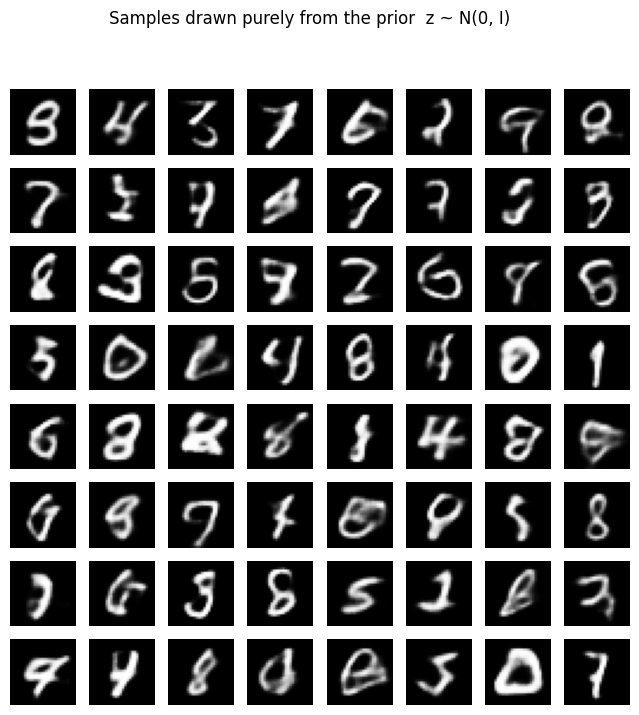

In [ ]:
model.eval()
n_samples = 64
with torch.no_grad():
    z = torch.randn(n_samples, LATENT_DIM).to(device)   # straight from the prior, no encoder involved at all
    samples = model.decoder(z).cpu()

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i, 0].numpy(), cmap="gray")
    ax.axis("off")
plt.suptitle("Samples drawn purely from the prior  z ~ N(0, I)")
plt.show()

This cell executes the training process again, but this time with a different `beta` value (`beta=4.0`).

*   It calls `train_vae` with `beta=4.0` to train a new VAE model (`model_beta4`).
*   The output shows the training progression for this `beta=4.0` run, allowing you to compare its loss curves and performance against the default `beta=1.0` model as suggested in the previous Markdown cell.

The last Markdown cell with id `F5Rb-6sE044K` provides guidance on what to include in the report.

This Markdown cell provides a summary of questions and considerations for the analysis and discussion section of your report. It encourages you to base your report on the actual results obtained from *your* VAE runs, rather than general theoretical claims. It covers:

*   **Reconstruction improvement**: Does the quality visibly improve or plateau?
*   **Interpolation quality**: Is the latent interpolation smooth and semantically meaningful?
*   **Prior sample quality**: Do samples from the prior look like recognizable digits, and what does this imply about the latent space coverage?
*   **Beta comparison**: A direct comparison of `beta=1` vs. `beta=4` based on your empirical results.

## 5. Comparing standard VAE vs. β-VAE

Re-run training with a different β (e.g. `beta=4.0`) to get a second model, and compare it against the β=1 run above. What to actually look at — not just report as a fact from the literature, but check in *your own* two runs:

- **Reconstruction sharpness** — higher β should trade off some reconstruction fidelity (more blur) for a more strongly regularized latent space.
- **The KL curve** — with β too high relative to the model's capacity, KL can collapse toward 0 early (posterior collapse, see the note above). If you see it, say so.
- **Interpolation smoothness** — a more regularized latent space (higher β) usually produces smoother, more semantically consistent interpolations, at the cost of blurrier endpoints.

In [ ]:
model_beta4, history_beta4, snapshots_beta4, _ = train_vae(beta=4.0)

epoch  1 | loss 205.58 | recon 183.83 | kl 5.44
epoch  2 | loss 159.56 | recon 124.80 | kl 8.69
epoch  3 | loss 154.60 | recon 116.87 | kl 9.43
epoch  4 | loss 152.44 | recon 113.58 | kl 9.71
epoch  5 | loss 151.01 | recon 111.65 | kl 9.84
epoch  6 | loss 149.86 | recon 110.23 | kl 9.91
epoch  7 | loss 149.03 | recon 109.16 | kl 9.97
epoch  8 | loss 148.33 | recon 108.27 | kl 10.01
epoch  9 | loss 147.73 | recon 107.55 | kl 10.04
epoch 10 | loss 147.21 | recon 106.92 | kl 10.07
epoch 11 | loss 146.72 | recon 106.40 | kl 10.08
epoch 12 | loss 146.45 | recon 106.07 | kl 10.09
epoch 13 | loss 146.00 | recon 105.63 | kl 10.09
epoch 14 | loss 145.72 | recon 105.26 | kl 10.12
epoch 15 | loss 145.47 | recon 104.96 | kl 10.13
